In [1]:
import matplotlib.pyplot as plt
import SimpleITK as sitk


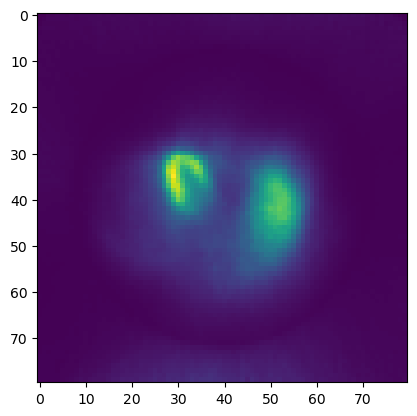

In [2]:
# 读取真实数据

filepath = r"./tomo.nii.gz"
image = sitk.ReadImage(filepath)
img_arr = sitk.GetArrayFromImage(image)[:,:, ::-1]  # 转换为 NumPy 数组


voxel_size = image.GetSpacing()[::-1]


plt.imshow(img_arr[27])




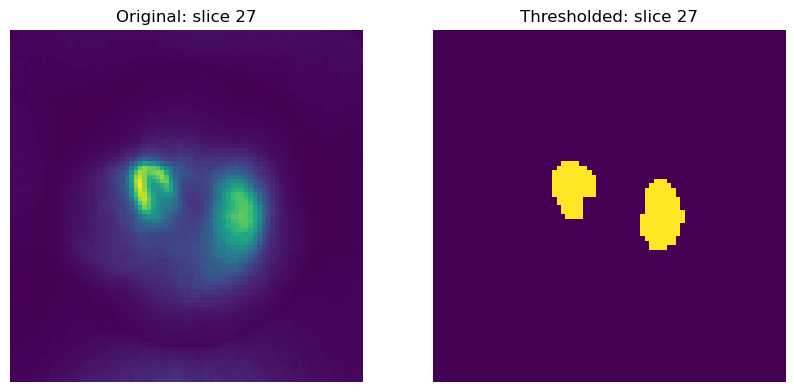

In [3]:
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(1, 2, 1)
plt.imshow(img_arr[27])
ax.set_title(f'Original: slice {27}')
ax.set_axis_off()
ax = plt.subplot(1, 2, 2)
plt.imshow(img_arr[27]>5)
ax.set_title(f'Thresholded: slice {27}')
ax.set_axis_off()
plt.show()





Found 2 clusters larger than 500mm2


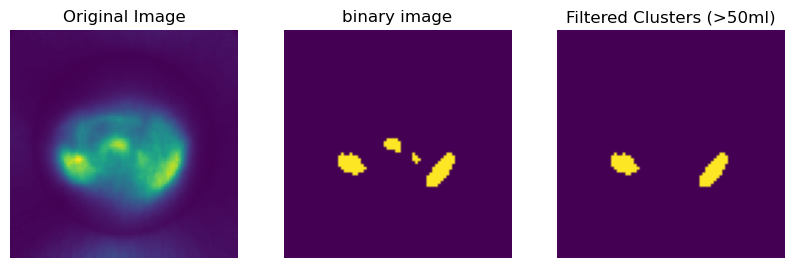

In [4]:
# 1. 去除小簇
from scipy import ndimage
import numpy as np


sid = 40
# 二值化图像
binary_img = img_arr[sid] > 5

# 标记连通区域
labeled_array, num_features = ndimage.label(binary_img)

# 计算每个簇的面积（单位：mm2）
cluster_sizes = []
for i in range(1, num_features + 1):
    cluster_size = np.sum(labeled_array == i) * voxel_size[1] * voxel_size[2]  # Convert to mm2
    cluster_sizes.append(cluster_size)

# 保留大于500mm2的簇
valid_clusters = []
for i, size in enumerate(cluster_sizes, 1):
    if size >= 2000:
        valid_clusters.append(i)

# 2&3. 分析剩余簇的最小包围矩形
if len(valid_clusters) == 1:
    # 获取唯一簇的坐标
    cluster = labeled_array == valid_clusters[0]
    coords = np.where(cluster)
    
    # 计算最小包围矩形的长宽
    y_min, y_max = np.min(coords[0]), np.max(coords[0])
    x_min, x_max = np.min(coords[1]), np.max(coords[1])
    
    width = (x_max - x_min) * voxel_size[2]  # Convert to cm
    height = (y_max - y_min) * voxel_size[1]  # Convert to cm
    
    # 判断是否为左心室
    is_lv = abs(width - height) < 2  # 长宽差小于2cm
    
    print(f"Found cluster with size {cluster_sizes[valid_clusters[0]-1]:.1f}mm2")
    print(f"Width: {width:.1f}cm, Height: {height:.1f}cm")
    print(f"Is likely left ventricle: {is_lv}")
else:
    print(f"Found {len(valid_clusters)} clusters larger than 500mm2")

# 显示筛选后结果
import matplotlib.pyplot as plt

# 创建筛选后的图像
filtered_array = np.zeros_like(labeled_array)
for cluster_id in valid_clusters:
    filtered_array[labeled_array == cluster_id] = cluster_id

# 创建一个新的图像
plt.figure(figsize=(10, 10))

# 显示原始图像
ax = plt.subplot(131)
plt.imshow(img_arr[sid])
ax.set_axis_off()
plt.title('Original Image')



ax = plt.subplot(132)
ax.set_axis_off()
plt.imshow(binary_img)
plt.title("binary image")

# 显示筛选后的图像（只显示大于500mm2的簇）
ax = plt.subplot(133)
ax.set_axis_off()
plt.imshow(filtered_array, vmax=1)
plt.title('Filtered Clusters (>50ml)')

plt.show()


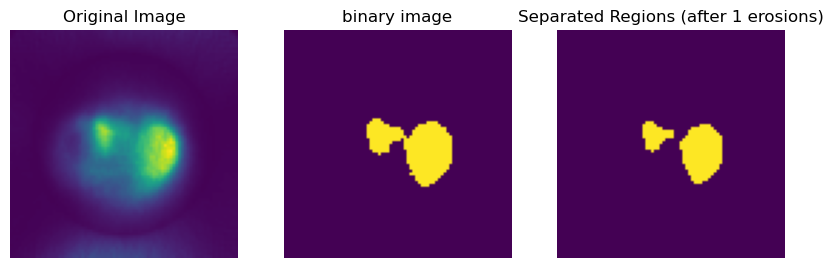

In [8]:
# 1. 去除小簇
from scipy import ndimage
import numpy as np

sid = 31
# 二值化图像
binary_img = img_arr[sid] > 4

# 创建一个新的图像
plt.figure(figsize=(10, 10))

# 显示原始图像
ax = plt.subplot(131)
plt.imshow(img_arr[sid])
ax.set_axis_off()
plt.title('Original Image')

ax = plt.subplot(132)
plt.title("binary image")
plt.imshow(binary_img)
ax.set_axis_off()


ax = plt.subplot(133)
ax.set_axis_off()

# 腐蚀操作直到分离
eroded = binary_img.copy()
num_regions = 1
iteration = 0

while num_regions == 1 and iteration < 10:
    eroded = ndimage.binary_erosion(eroded)
    labeled_eroded, num_regions = ndimage.label(eroded)
    iteration += 1

if num_regions >= 2:
    # 获取两个最大的区域
    sizes = ndimage.sum(eroded, labeled_eroded, range(num_regions + 1))
    sorted_regions = np.argsort(sizes)[-2:]  # 获取最大的两个区域
    
    # 创建掩码
    result = np.zeros_like(binary_img)
    result[labeled_eroded == sorted_regions[-1]] = 1  # 最大区域
    result[labeled_eroded == sorted_regions[-2]] = 2  # 第二大区域
    
    plt.imshow(result, cmap='viridis')
    plt.title(f'Separated Regions (after {iteration} erosions)')
else:
    plt.imshow(binary_img)
    plt.title('Binary Image (no separation achieved)')

plt.show()


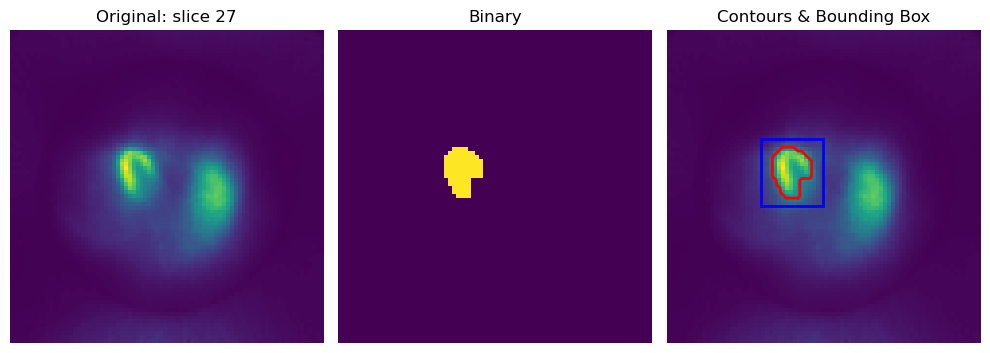

In [6]:
from skimage import measure

fig = plt.figure(figsize=(10, 10))

# 原始图像
ax = plt.subplot(1, 3, 1)
plt.imshow(img_arr[27])
ax.set_title(f'Original: slice {27}')
ax.set_axis_off()

# 二值化图像
binary = img_arr[27] > 5

binary[:, 40:]=0
ax = plt.subplot(1, 3, 2)
plt.imshow(binary)
ax.set_title('Binary')
ax.set_axis_off()

# 找到轮廓和最小外接矩形
ax = plt.subplot(1, 3, 3)
plt.imshow(img_arr[27])

# 找到轮廓
contours = measure.find_contours(binary, 0.5)

# 画出所有轮廓
for contour in contours:
    plt.plot(contour[:, 1], contour[:, 0], 'r', linewidth=2)
    
    # 计算最小外接矩形
    y_min, x_min = np.min(contour, axis=0)
    y_max, x_max = np.max(contour, axis=0)
    
    # 画矩形
    rect = plt.Rectangle((x_min-3, y_min-2), x_max-x_min+6, y_max-y_min+4,
                        fill=False, color='b', linewidth=2)
    ax.add_patch(rect)

ax.set_title('Contours & Bounding Box')
ax.set_axis_off()

plt.tight_layout()
plt.show()
